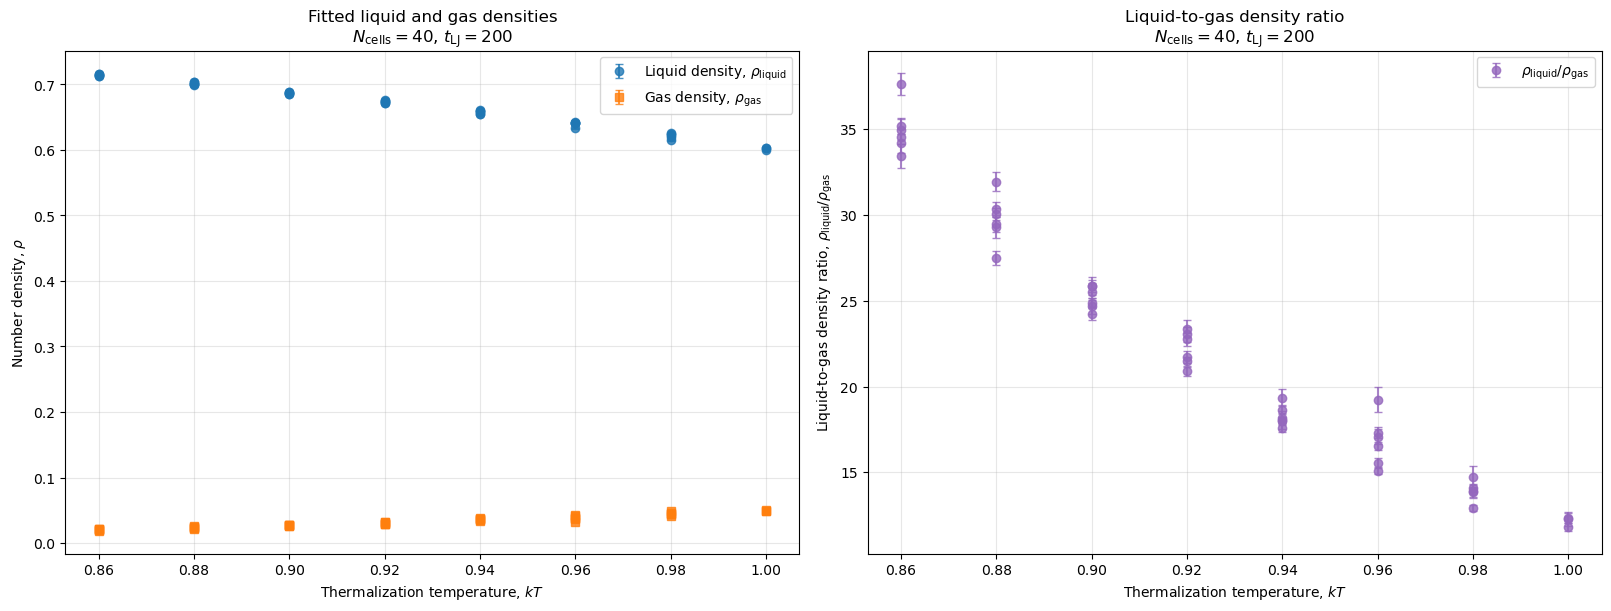

Density plot: 44 matching runs.
Ratio plot: 44 of 44 runs with complete fit uncertainties.

Phase-density data:


,Run_ID,Therm_kT,rho_liquid,rho_liquid_unc,rho_gas,rho_gas_unc
0,20260915173225,0.86,0.715765,0.000391,0.020711,0.00026
1,20260915173427,0.86,0.716306,0.000365,0.020359,0.000272
2,20260915173627,0.86,0.713656,0.000371,0.020874,0.00033
3,20260915173827,0.86,0.71347,0.000351,0.018954,0.000311
4,20260915174027,0.86,0.714967,0.000346,0.020446,0.000358
5,20260915174228,0.86,0.713072,0.000346,0.02132,0.000442
6,20260915174430,0.88,0.703266,0.000388,0.023396,0.000289
7,20260915174630,0.88,0.700387,0.000389,0.023085,0.000329
8,20260915174829,0.88,0.699625,0.000381,0.02546,0.000378
9,20260915175032,0.88,0.701079,0.000362,0.023764,0.000389



Density-ratio data:


,Run_ID,Therm_kT,rho_liquid_to_gas,ratio_unc,gas_relative_unc
0,20260915173225,0.86,34.560153,0.434525,0.012561
1,20260915173427,0.86,35.184482,0.470216,0.013355
2,20260915173627,0.86,34.188085,0.540064,0.015788
3,20260915173827,0.86,37.642945,0.617467,0.016396
4,20260915174027,0.86,34.968743,0.612418,0.017507
5,20260915174228,0.86,33.445799,0.693565,0.020731
6,20260915174430,0.88,30.059536,0.371478,0.012346
7,20260915174630,0.88,30.339878,0.432118,0.014232
8,20260915174829,0.88,27.479234,0.408437,0.014853
9,20260915175032,0.88,29.501239,0.482757,0.016356


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
    thermalization_dataframe,
)


# ============================================================
# Select matching thermalization runs
# ============================================================

paths = ProjectPaths()
database = SQLiteRunDatabase(paths.database)

matches = thermalization_dataframe(
    database,
    N_Cells=40,
    Cumulative_LJ_Time=200,
    Phase_Separation_Status="Separated",
    rho_gas_unc=(None, 0.002),
    Therm_kT=(0.85, None),
    Clone_Run_ID=None,
)


# ============================================================
# Prepare fitted phase-density data
# ============================================================

required_columns = [
    "Run_ID",
    "Therm_kT",
    "rho_liquid",
    "rho_liquid_unc",
    "rho_gas",
    "rho_gas_unc",
]

missing_columns = [
    column
    for column in required_columns
    if column not in matches.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )

plot_data = matches[required_columns].copy()

numeric_columns = [
    "Therm_kT",
    "rho_liquid",
    "rho_liquid_unc",
    "rho_gas",
    "rho_gas_unc",
]

for column in numeric_columns:
    plot_data[column] = pd.to_numeric(
        plot_data[column],
        errors="coerce",
    )

plot_data = (
    plot_data
    .dropna(
        subset=[
            "Therm_kT",
            "rho_liquid",
            "rho_gas",
        ]
    )
    .sort_values(["Therm_kT", "Run_ID"])
    .reset_index(drop=True)
)

if plot_data.empty:
    raise ValueError(
        "The matching runs do not contain successful "
        "liquid/gas density fits."
    )


# ============================================================
# Arrays for the liquid and gas density plot
# ============================================================

temperature = plot_data[
    "Therm_kT"
].to_numpy(dtype=float)

rho_liquid = plot_data[
    "rho_liquid"
].to_numpy(dtype=float)

rho_gas = plot_data[
    "rho_gas"
].to_numpy(dtype=float)

rho_liquid_unc = plot_data[
    "rho_liquid_unc"
].to_numpy(dtype=float)

rho_gas_unc = plot_data[
    "rho_gas_unc"
].to_numpy(dtype=float)

# Missing uncertainties are displayed without an error-bar extent.
rho_liquid_unc_plot = np.where(
    np.isfinite(rho_liquid_unc),
    rho_liquid_unc,
    0.0,
)

rho_gas_unc_plot = np.where(
    np.isfinite(rho_gas_unc),
    rho_gas_unc,
    0.0,
)


# ============================================================
# Calculate liquid-to-gas density ratio
#
# Assumes the liquid and gas fit errors are uncorrelated.
# ============================================================

ratio_data = plot_data.copy()

# Do not treat missing uncertainties as zero in the ratio.
ratio_data = ratio_data.dropna(
    subset=numeric_columns
).copy()

ratio_data = ratio_data.loc[
    (ratio_data["rho_liquid"] > 0)
    & (ratio_data["rho_gas"] > 0)
    & (ratio_data["rho_liquid_unc"] >= 0)
    & (ratio_data["rho_gas_unc"] >= 0)
].copy()

if ratio_data.empty:
    raise ValueError(
        "No runs have positive phase densities and both "
        "fit uncertainties."
    )

ratio_data["rho_liquid_to_gas"] = (
    ratio_data["rho_liquid"]
    / ratio_data["rho_gas"]
)

ratio_data["ratio_unc"] = (
    ratio_data["rho_liquid_to_gas"]
    * np.sqrt(
        (
            ratio_data["rho_liquid_unc"]
            / ratio_data["rho_liquid"]
        ) ** 2
        + (
            ratio_data["rho_gas_unc"]
            / ratio_data["rho_gas"]
        ) ** 2
    )
)

ratio_data["gas_relative_unc"] = (
    ratio_data["rho_gas_unc"]
    / ratio_data["rho_gas"]
)

ratio_data = ratio_data.sort_values(
    ["Therm_kT", "Run_ID"]
).reset_index(drop=True)


# ============================================================
# Plot both results side by side
# ============================================================

fig, (ax_density, ax_ratio) = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    constrained_layout=True,
)


# ------------------------------------------------------------
# Left: separate liquid and gas densities
# ------------------------------------------------------------

ax_density.errorbar(
    temperature,
    rho_liquid,
    yerr=rho_liquid_unc_plot,
    fmt="o",
    markersize=6,
    capsize=3,
    color="tab:blue",
    alpha=0.8,
    linestyle="none",
    label=r"Liquid density, $\rho_{\mathrm{liquid}}$",
)

ax_density.errorbar(
    temperature,
    rho_gas,
    yerr=rho_gas_unc_plot,
    fmt="s",
    markersize=6,
    capsize=3,
    color="tab:orange",
    alpha=0.8,
    linestyle="none",
    label=r"Gas density, $\rho_{\mathrm{gas}}$",
)

ax_density.set_xlabel(
    r"Thermalization temperature, $kT$"
)

ax_density.set_ylabel(
    r"Number density, $\rho$"
)

ax_density.set_title(
    "Fitted liquid and gas densities\n"
    r"$N_{\mathrm{cells}}=40$, "
    r"$t_{\mathrm{LJ}}=200$"
)

ax_density.grid(alpha=0.3)
ax_density.legend()


# ------------------------------------------------------------
# Right: liquid-to-gas density ratio
# ------------------------------------------------------------

ax_ratio.errorbar(
    ratio_data["Therm_kT"].to_numpy(dtype=float),
    ratio_data[
        "rho_liquid_to_gas"
    ].to_numpy(dtype=float),
    yerr=ratio_data[
        "ratio_unc"
    ].to_numpy(dtype=float),
    fmt="o",
    markersize=6,
    linestyle="none",
    capsize=3,
    color="tab:purple",
    alpha=0.8,
    label=(
        r"$\rho_{\mathrm{liquid}}/"
        r"\rho_{\mathrm{gas}}$"
    ),
)

ax_ratio.set_xlabel(
    r"Thermalization temperature, $kT$"
)

ax_ratio.set_ylabel(
    r"Liquid-to-gas density ratio, "
    r"$\rho_{\mathrm{liquid}}/"
    r"\rho_{\mathrm{gas}}$"
)

ax_ratio.set_title(
    "Liquid-to-gas density ratio\n"
    r"$N_{\mathrm{cells}}=40$, "
    r"$t_{\mathrm{LJ}}=200$"
)

ax_ratio.grid(alpha=0.3)
ax_ratio.legend()

plt.show()


# ============================================================
# Diagnostics and exact plotted values
# ============================================================

print(
    f"Density plot: {len(plot_data)} matching runs."
)

print(
    f"Ratio plot: {len(ratio_data)} of "
    f"{len(plot_data)} runs with complete fit uncertainties."
)

if (ratio_data["gas_relative_unc"] > 0.2).any():
    print(
        "Caution: some vapor-density uncertainties exceed "
        "20% of the fitted vapor density. First-order "
        "symmetric ratio error bars may be a poor "
        "approximation for those points."
    )

print("\nPhase-density data:")
display(
    plot_data[
        [
            "Run_ID",
            "Therm_kT",
            "rho_liquid",
            "rho_liquid_unc",
            "rho_gas",
            "rho_gas_unc",
        ]
    ]
)

print("\nDensity-ratio data:")
display(
    ratio_data[
        [
            "Run_ID",
            "Therm_kT",
            "rho_liquid_to_gas",
            "ratio_unc",
            "gas_relative_unc",
        ]
    ]
)

Fitted epsilon/kB: 128.600 ± 0.042 K
Points fitted:      44
Chi-square:         318.60
Degrees of freedom: 43
Reduced chi-square: 7.41


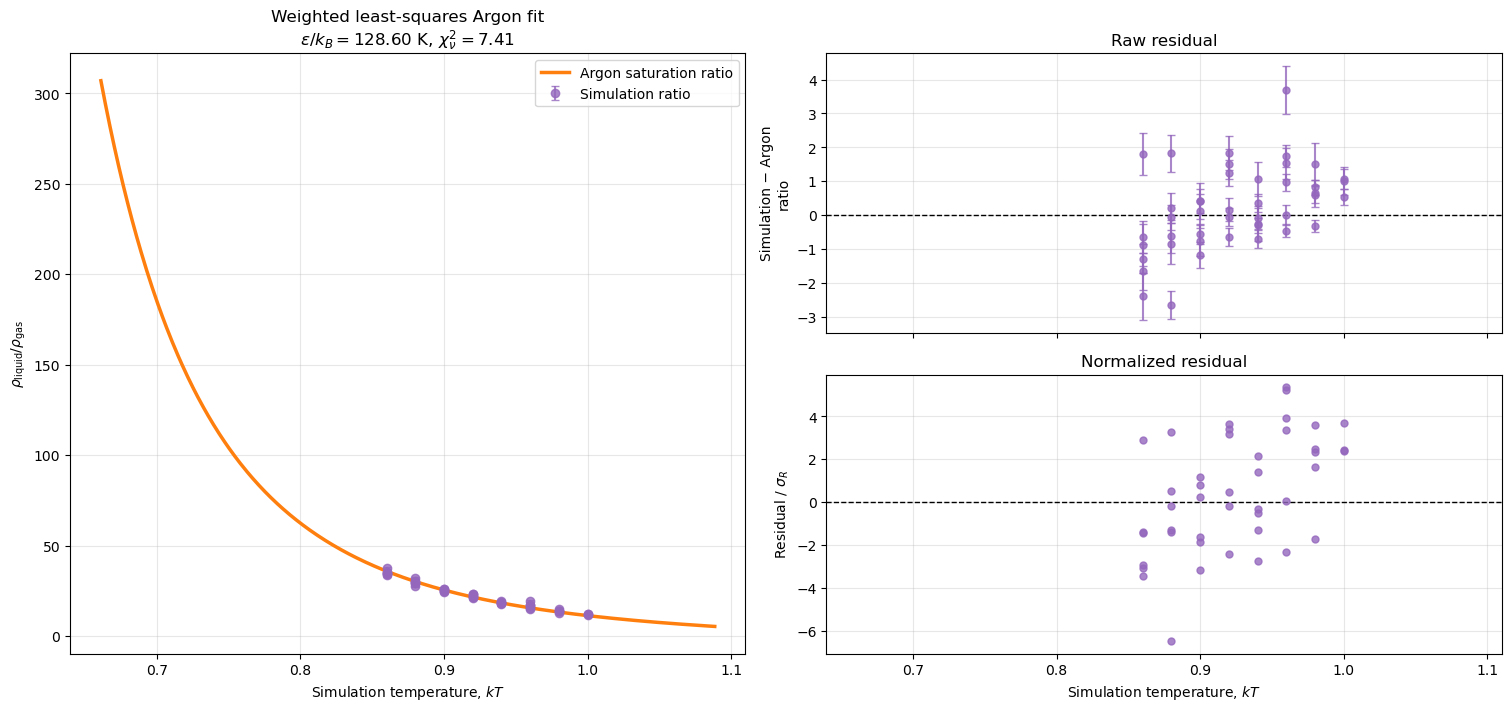

,Run_ID,Therm_kT,rho_liquid_to_gas,ratio_unc,argon_ratio_at_fitted_T,raw_residual,weighted_residual
0,20260915173225,0.86,34.560153,0.434525,35.838444,-1.278290,-2.941808
1,20260915173427,0.86,35.184482,0.470216,35.838444,-0.653961,-1.390768
2,20260915173627,0.86,34.188085,0.540064,35.838444,-1.650359,-3.055860
3,20260915173827,0.86,37.642945,0.617467,35.838444,1.804501,2.922424
4,20260915174027,0.86,34.968743,0.612418,35.838444,-0.869701,-1.420110
5,20260915174228,0.86,33.445799,0.693565,35.838444,-2.392644,-3.449775
6,20260915174430,0.88,30.059536,0.371478,30.122152,-0.062616,-0.168560
7,20260915174630,0.88,30.339878,0.432118,30.122152,0.217726,0.503857
8,20260915174829,0.88,27.479234,0.408437,30.122152,-2.642919,-6.470817
9,20260915175032,0.88,29.501239,0.482757,30.122152,-0.620914,-1.286183


In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares


# ============================================================
# Load the Argon saturation table
# ============================================================

argon_path = (
    Path("/home/pnichols/MDsims/Tech Note/Argon Like")
    / "argon_saturation_clean.csv"
)

if not argon_path.exists():
    raise FileNotFoundError(
        f"Missing Argon table: {argon_path}"
    )

argon = pd.read_csv(argon_path)

argon_T = pd.to_numeric(
    argon["temperature_K"],
    errors="coerce",
).to_numpy(dtype=float)

argon_ratio = (
    pd.to_numeric(
        argon["density_liquid_mol_L"],
        errors="coerce",
    )
    / pd.to_numeric(
        argon["density_vapor_mol_L"],
        errors="coerce",
    )
).to_numpy(dtype=float)

valid_argon = (
    np.isfinite(argon_T)
    & np.isfinite(argon_ratio)
    & (argon_ratio > 0)
)

argon_T = argon_T[valid_argon]
argon_ratio = argon_ratio[valid_argon]

order = np.argsort(argon_T)
argon_T = argon_T[order]
argon_ratio = argon_ratio[order]

if (
    len(argon_T) < 2
    or np.any(np.diff(argon_T) <= 0)
):
    raise ValueError(
        "Argon temperatures must be unique and increasing."
    )


# ============================================================
# Prepare the simulation ratio data
# ============================================================

# Use the propagated uncertainties from the previous cell.
fit_data = ratio_data.copy()

for column in [
    "Therm_kT",
    "rho_liquid_to_gas",
    "ratio_unc",
]:
    fit_data[column] = pd.to_numeric(
        fit_data[column],
        errors="coerce",
    )

fit_data = fit_data.dropna(
    subset=[
        "Therm_kT",
        "rho_liquid_to_gas",
        "ratio_unc",
    ]
)

fit_data = fit_data.loc[
    (fit_data["Therm_kT"] > 0)
    & (fit_data["rho_liquid_to_gas"] > 0)
    & (fit_data["ratio_unc"] > 0)
].copy()


# ============================================================
# Fix the fitted point set before optimization
# ============================================================

initial_scale_K = 132

fit_data = fit_data.loc[
    (
        initial_scale_K
        * fit_data["Therm_kT"]
    ).between(
        argon_T.min(),
        argon_T.max(),
    )
].copy()

if len(fit_data) < 3:
    raise ValueError(
        "Fewer than three simulation points overlap the "
        "Argon temperature range at the initial scale."
    )

x = fit_data[
    "Therm_kT"
].to_numpy(dtype=float)

y = fit_data[
    "rho_liquid_to_gas"
].to_numpy(dtype=float)

y_unc = fit_data[
    "ratio_unc"
].to_numpy(dtype=float)


# ============================================================
# Temperature-scale bounds
# ============================================================

# These bounds ensure every selected simulation point remains
# inside the Argon table during optimization.
scale_lower = argon_T.min() / x.min()
scale_upper = argon_T.max() / x.max()

if scale_lower >= scale_upper:
    raise ValueError(
        "The selected simulation temperatures cannot all "
        "be mapped inside the Argon table with one "
        "temperature scale."
    )


# ============================================================
# Weighted least-squares fit
# ============================================================

def weighted_residual(parameters):
    trial_scale_K = parameters[0]

    predicted_ratio = np.interp(
        trial_scale_K * x,
        argon_T,
        argon_ratio,
    )

    return (
        y - predicted_ratio
    ) / y_unc


fit = least_squares(
    weighted_residual,
    x0=[
        np.clip(
            initial_scale_K,
            scale_lower,
            scale_upper,
        )
    ],
    bounds=(
        [scale_lower],
        [scale_upper],
    ),
)

if not fit.success:
    raise RuntimeError(
        f"Least-squares fit failed: {fit.message}"
    )


# ============================================================
# Evaluate the best-fitting model
# ============================================================

scale_K = float(fit.x[0])

predicted = np.interp(
    scale_K * x,
    argon_T,
    argon_ratio,
)

# Raw residual in the original ratio units.
difference = y - predicted

# Normalized residual, or z-score.
weighted_resid = difference / y_unc

chi2 = float(
    np.sum(weighted_resid**2)
)

dof = len(x) - 1
reduced_chi2 = chi2 / dof


# ============================================================
# Local uncertainty in the fitted temperature scale
# ============================================================

jacobian = fit.jac[:, 0]

scale_unc_K = (
    1 / np.sqrt(np.sum(jacobian**2))
    if np.sum(jacobian**2) > 0
    else np.nan
)


# ============================================================
# Save calculated values
# ============================================================

fit_data["argon_ratio_at_fitted_T"] = predicted
fit_data["raw_residual"] = difference
fit_data["weighted_residual"] = weighted_resid


# ============================================================
# Print fit statistics
# ============================================================

print(
    f"Fitted epsilon/kB: "
    f"{scale_K:.3f} ± {scale_unc_K:.3f} K"
)

print(f"Points fitted:      {len(x)}")
print(f"Chi-square:         {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"Reduced chi-square: {reduced_chi2:.2f}")

if (
    np.isclose(scale_K, scale_lower)
    or np.isclose(scale_K, scale_upper)
):
    print(
        "Caution: the optimum is at a temperature-range "
        "bound; the reported symmetric scale uncertainty "
        "is unreliable."
    )


# ============================================================
# Plot layout
#
# Left:
#   Main simulation and Argon ratio comparison
#
# Upper right:
#   Raw residual in ratio units
#
# Lower right:
#   Normalized residual / z-score
# ============================================================

fig = plt.figure(
    figsize=(15, 7),
    constrained_layout=True,
)

grid = fig.add_gridspec(
    2,
    2,
    width_ratios=[1.0, 1.0],
    height_ratios=[1, 1],
)

# Main plot spans both rows on the left.
ax_ratio = fig.add_subplot(
    grid[:, 0]
)

# Residual plots are stacked on the right.
ax_diff = fig.add_subplot(
    grid[0, 1],
    sharex=ax_ratio,
)

ax_resid = fig.add_subplot(
    grid[1, 1],
    sharex=ax_ratio,
)


# ------------------------------------------------------------
# Left: original ratio data and fitted Argon curve
# ------------------------------------------------------------

ax_ratio.plot(
    argon_T / scale_K,
    argon_ratio,
    color="tab:orange",
    linewidth=2.5,
    label="Argon saturation ratio",
)

ax_ratio.errorbar(
    x,
    y,
    yerr=y_unc,
    fmt="o",
    linestyle="none",
    markersize=6,
    capsize=3,
    color="tab:purple",
    alpha=0.8,
    label="Simulation ratio",
)

ax_ratio.set_xlabel(
    r"Simulation temperature, $kT$"
)

ax_ratio.set_ylabel(
    r"$\rho_{\mathrm{liquid}}/"
    r"\rho_{\mathrm{gas}}$"
)

ax_ratio.set_title(
    "Weighted least-squares Argon fit\n"
    rf"$\epsilon/k_B={scale_K:.2f}$ K, "
    rf"$\chi^2_\nu={reduced_chi2:.2f}$"
)

ax_ratio.grid(alpha=0.3)
ax_ratio.legend()


# ------------------------------------------------------------
# Upper right: raw residual
# ------------------------------------------------------------

ax_diff.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax_diff.errorbar(
    x,
    difference,
    yerr=y_unc,
    fmt="o",
    linestyle="none",
    markersize=5,
    capsize=3,
    color="tab:purple",
    alpha=0.8,
)

ax_diff.set_title(
    "Raw residual"
)

ax_diff.set_ylabel(
    "Simulation − Argon\nratio"
)

ax_diff.grid(alpha=0.3)

# The lower-right plot supplies the x-axis labels.
ax_diff.tick_params(
    axis="x",
    labelbottom=False,
)


# ------------------------------------------------------------
# Lower right: normalized residual / z-score
# ------------------------------------------------------------

ax_resid.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax_resid.plot(
    x,
    weighted_resid,
    "o",
    markersize=5,
    color="tab:purple",
    alpha=0.8,
)

ax_resid.set_title(
    "Normalized residual"
)

ax_resid.set_xlabel(
    r"Simulation temperature, $kT$"
)

ax_resid.set_ylabel(
    r"Residual / $\sigma_R$"
)

ax_resid.grid(alpha=0.3)

plt.show()


# ============================================================
# Display exact fitted and residual values
# ============================================================

display(
    fit_data[
        [
            "Run_ID",
            "Therm_kT",
            "rho_liquid_to_gas",
            "ratio_unc",
            "argon_ratio_at_fitted_T",
            "raw_residual",
            "weighted_residual",
        ]
    ]
)

Temperature scale, epsilon/kB: 128.600 ± 0.042 K
Density scale: 43.8324 ± 0.0038 (mol/L per simulation-density unit)
Implied LJ sigma: 0.33585 ± 0.00001 nm = 3.3585 ± 0.0001 Å
Density-fit reduced chi-square: 173.39
Liquid-only density scale: 43.8322 (mol/L per simulation-density unit)
Vapor-only density scale: 43.9197 (mol/L per simulation-density unit)


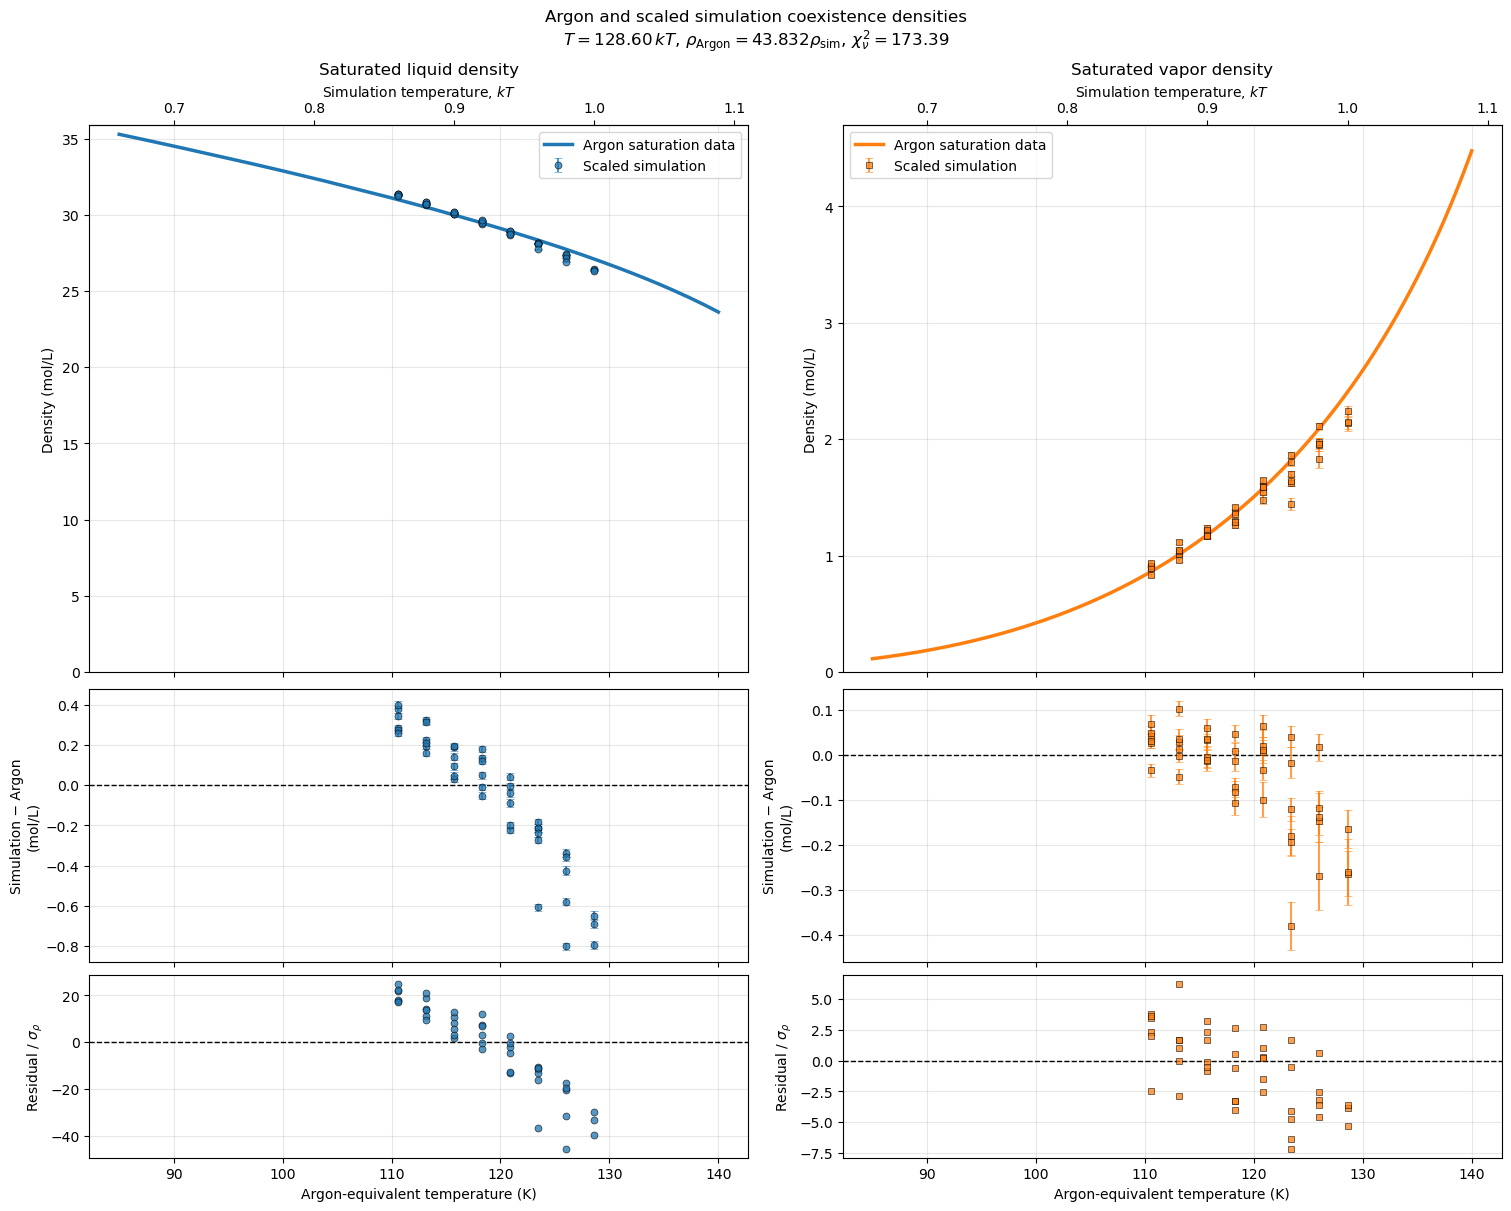

,Run_ID,Therm_kT,temperature_K,rho_liquid,rho_liquid_unc,rho_gas,rho_gas_unc,rho_liquid_scaled_mol_L,rho_liquid_scaled_unc_mol_L,argon_liquid_mol_L,liquid_residual_mol_L,liquid_z_score,rho_vapor_scaled_mol_L,rho_vapor_scaled_unc_mol_L,argon_vapor_mol_L,vapor_residual_mol_L,vapor_z_score
0,20260915173225,0.86,110.595614,0.715765,0.000391,0.020711,0.00026,31.37366,0.017151,30.997833,0.375826,21.912994,0.907799,0.011403,0.864934,0.042865,3.759073
1,20260915173427,0.86,110.595614,0.716306,0.000365,0.020359,0.000272,31.397358,0.016014,30.997833,0.399525,24.948144,0.892364,0.011917,0.864934,0.02743,2.301711
2,20260915173627,0.86,110.595614,0.713656,0.000371,0.020874,0.00033,31.281232,0.016256,30.997833,0.283398,17.433216,0.914975,0.014446,0.864934,0.050041,3.464008
3,20260915173827,0.86,110.595614,0.71347,0.000351,0.018954,0.000311,31.273082,0.015371,30.997833,0.275249,17.90691,0.830782,0.013621,0.864934,-0.034152,-2.507226
4,20260915174027,0.86,110.595614,0.714967,0.000346,0.020446,0.000358,31.338678,0.015165,30.997833,0.340845,22.475643,0.896191,0.015689,0.864934,0.031257,1.992263
5,20260915174228,0.86,110.595614,0.713072,0.000346,0.02132,0.000442,31.255631,0.01518,30.997833,0.257798,16.982359,0.934516,0.019374,0.864934,0.069582,3.591558
6,20260915174430,0.88,113.167605,0.703266,0.000388,0.023396,0.000289,30.825814,0.016997,30.505155,0.320658,18.866003,1.025492,0.01266,1.012724,0.012768,1.008501
7,20260915174630,0.88,113.167605,0.700387,0.000389,0.023085,0.000329,30.699601,0.017068,30.505155,0.194446,11.392146,1.011856,0.0144,1.012724,-0.000867,-0.060238
8,20260915174829,0.88,113.167605,0.699625,0.000381,0.02546,0.000378,30.666232,0.016695,30.505155,0.161077,9.648131,1.115978,0.016576,1.012724,0.103255,6.229094
9,20260915175032,0.88,113.167605,0.701079,0.000362,0.023764,0.000389,30.729935,0.015868,30.505155,0.22478,14.165908,1.041649,0.017037,1.012724,0.028925,1.69778


In [28]:
# ============================================================
# Fit a common density scale and compare each phase to Argon
# ============================================================

# Use exactly the runs retained by the temperature-ratio fit.
density_data = fit_data[
    [
        "Run_ID",
        "Therm_kT",
        "rho_liquid",
        "rho_liquid_unc",
        "rho_gas",
        "rho_gas_unc",
    ]
].copy()

numeric_columns = [
    "Therm_kT",
    "rho_liquid",
    "rho_liquid_unc",
    "rho_gas",
    "rho_gas_unc",
]

for column in numeric_columns:
    density_data[column] = pd.to_numeric(
        density_data[column],
        errors="coerce",
    )

density_data = density_data.dropna(
    subset=numeric_columns
).copy()

density_data = density_data.loc[
    (density_data["Therm_kT"] > 0)
    & (density_data["rho_liquid"] > 0)
    & (density_data["rho_gas"] > 0)
    & (density_data["rho_liquid_unc"] > 0)
    & (density_data["rho_gas_unc"] > 0)
].copy()

# Temperature mapping obtained from the liquid/vapor ratio:
#
# T_Argon [K] = scale_K * kT_sim
#
density_data["temperature_K"] = (
    scale_K * density_data["Therm_kT"]
)


# ============================================================
# Prepare the Argon liquid and vapor density curves
# ============================================================

argon_density = argon[
    [
        "temperature_K",
        "density_liquid_mol_L",
        "density_vapor_mol_L",
    ]
].copy()

argon_density = (
    argon_density
    .apply(pd.to_numeric, errors="coerce")
    .dropna()
    .sort_values("temperature_K")
    .drop_duplicates("temperature_K")
    .reset_index(drop=True)
)

argon_temperature = argon_density[
    "temperature_K"
].to_numpy(dtype=float)

argon_liquid = argon_density[
    "density_liquid_mol_L"
].to_numpy(dtype=float)

argon_vapor = argon_density[
    "density_vapor_mol_L"
].to_numpy(dtype=float)

# Retain only simulation temperatures covered by the Argon table.
density_data = density_data.loc[
    density_data["temperature_K"].between(
        argon_temperature.min(),
        argon_temperature.max(),
    )
].copy()

if density_data.empty:
    raise ValueError(
        "No simulation points fall inside the Argon temperature range."
    )

density_data["argon_liquid_mol_L"] = np.interp(
    density_data["temperature_K"],
    argon_temperature,
    argon_liquid,
)

density_data["argon_vapor_mol_L"] = np.interp(
    density_data["temperature_K"],
    argon_temperature,
    argon_vapor,
)


# ============================================================
# Fit one common density multiplier
#
# rho_Argon [mol/L] = density_scale * rho_sim
#
# The fit is performed in log-density space and weighted by
# fractional simulation uncertainty. This prevents the larger
# liquid densities from completely dominating the vapor data.
# ============================================================

liquid_points = pd.DataFrame(
    {
        "phase": "Liquid",
        "rho_sim": density_data["rho_liquid"],
        "rho_sim_unc": density_data["rho_liquid_unc"],
        "rho_argon": density_data["argon_liquid_mol_L"],
    }
)

vapor_points = pd.DataFrame(
    {
        "phase": "Vapor",
        "rho_sim": density_data["rho_gas"],
        "rho_sim_unc": density_data["rho_gas_unc"],
        "rho_argon": density_data["argon_vapor_mol_L"],
    }
)

density_fit_points = pd.concat(
    [liquid_points, vapor_points],
    ignore_index=True,
)

density_fit_points["relative_unc"] = (
    density_fit_points["rho_sim_unc"]
    / density_fit_points["rho_sim"]
)

density_fit_points["log_scale_needed"] = np.log(
    density_fit_points["rho_argon"]
    / density_fit_points["rho_sim"]
)

density_fit_points["weight"] = (
    1.0 / density_fit_points["relative_unc"] ** 2
)

log_density_scale = np.average(
    density_fit_points["log_scale_needed"],
    weights=density_fit_points["weight"],
)

density_scale = float(np.exp(log_density_scale))

# Formal local 1-sigma uncertainty. This treats scale_K and
# the tabulated Argon densities as fixed.
log_density_scale_unc = float(
    1.0 / np.sqrt(density_fit_points["weight"].sum())
)

density_scale_unc = (
    density_scale * log_density_scale_unc
)

density_fit_points["weighted_log_residual"] = (
    np.log(
        density_scale
        * density_fit_points["rho_sim"]
        / density_fit_points["rho_argon"]
    )
    / density_fit_points["relative_unc"]
)

density_chi2 = float(
    np.sum(
        density_fit_points["weighted_log_residual"] ** 2
    )
)

density_dof = len(density_fit_points) - 1
density_reduced_chi2 = density_chi2 / density_dof


# ============================================================
# Convert the density scale into the corresponding LJ sigma
#
# rho_mol/L = rho* / (0.602214076 * sigma_nm^3)
# ============================================================

sigma_nm = (
    1.0 / (0.602214076 * density_scale)
) ** (1.0 / 3.0)

sigma_unc_nm = (
    sigma_nm
    * density_scale_unc
    / (3.0 * density_scale)
)

print(
    f"Temperature scale, epsilon/kB: "
    f"{scale_K:.3f} ± {scale_unc_K:.3f} K"
)

print(
    f"Density scale: "
    f"{density_scale:.4f} ± {density_scale_unc:.4f} "
    "(mol/L per simulation-density unit)"
)

print(
    f"Implied LJ sigma: "
    f"{sigma_nm:.5f} ± {sigma_unc_nm:.5f} nm "
    f"= {10 * sigma_nm:.4f} ± "
    f"{10 * sigma_unc_nm:.4f} Å"
)

print(
    f"Density-fit reduced chi-square: "
    f"{density_reduced_chi2:.2f}"
)

# Phase-only scale estimates diagnose whether one shared scale
# can describe both liquid and vapor.
for phase in ["Liquid", "Vapor"]:
    phase_points = density_fit_points.loc[
        density_fit_points["phase"] == phase
    ]

    phase_log_scale = np.average(
        phase_points["log_scale_needed"],
        weights=phase_points["weight"],
    )

    print(
        f"{phase}-only density scale: "
        f"{np.exp(phase_log_scale):.4f} "
        "(mol/L per simulation-density unit)"
    )


# ============================================================
# Apply the common density scale
# ============================================================

density_data["rho_liquid_scaled_mol_L"] = (
    density_scale * density_data["rho_liquid"]
)

density_data["rho_liquid_scaled_unc_mol_L"] = (
    density_scale * density_data["rho_liquid_unc"]
)

density_data["rho_vapor_scaled_mol_L"] = (
    density_scale * density_data["rho_gas"]
)

density_data["rho_vapor_scaled_unc_mol_L"] = (
    density_scale * density_data["rho_gas_unc"]
)


# ============================================================
# Calculate raw residuals
#
# residual = scaled simulation - Argon
# ============================================================

density_data["liquid_residual_mol_L"] = (
    density_data["rho_liquid_scaled_mol_L"]
    - density_data["argon_liquid_mol_L"]
)

density_data["vapor_residual_mol_L"] = (
    density_data["rho_vapor_scaled_mol_L"]
    - density_data["argon_vapor_mol_L"]
)


# ============================================================
# Calculate z-scores using the same convention as the ratio fit
#
# z = residual / scaled simulation uncertainty
# ============================================================

density_data["liquid_z_score"] = (
    density_data["liquid_residual_mol_L"]
    / density_data["rho_liquid_scaled_unc_mol_L"]
)

density_data["vapor_z_score"] = (
    density_data["vapor_residual_mol_L"]
    / density_data["rho_vapor_scaled_unc_mol_L"]
)

density_data = density_data.sort_values(
    ["temperature_K", "Run_ID"]
).reset_index(drop=True)


# ============================================================
# Plot density, raw residual, and z-score
#
# Left column:  liquid
# Right column: vapor
# ============================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(15, 12),
    sharex="col",
    gridspec_kw={
        "height_ratios": [3.0, 1.5, 1.0],
    },
    constrained_layout=True,
)

phase_plot_settings = [
    {
        "column": 0,
        "name": "Liquid",
        "color": "tab:blue",
        "marker": "o",
        "argon_curve": argon_liquid,
        "sim_density": "rho_liquid_scaled_mol_L",
        "sim_unc": "rho_liquid_scaled_unc_mol_L",
        "residual": "liquid_residual_mol_L",
        "z_score": "liquid_z_score",
    },
    {
        "column": 1,
        "name": "Vapor",
        "color": "tab:orange",
        "marker": "s",
        "argon_curve": argon_vapor,
        "sim_density": "rho_vapor_scaled_mol_L",
        "sim_unc": "rho_vapor_scaled_unc_mol_L",
        "residual": "vapor_residual_mol_L",
        "z_score": "vapor_z_score",
    },
]

for settings in phase_plot_settings:
    column = settings["column"]

    ax_density = axes[0, column]
    ax_residual = axes[1, column]
    ax_z_score = axes[2, column]

    temperature_K = density_data[
        "temperature_K"
    ].to_numpy(dtype=float)

    sim_density = density_data[
        settings["sim_density"]
    ].to_numpy(dtype=float)

    sim_unc = density_data[
        settings["sim_unc"]
    ].to_numpy(dtype=float)

    residual = density_data[
        settings["residual"]
    ].to_numpy(dtype=float)

    z_score = density_data[
        settings["z_score"]
    ].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Density comparison
    # --------------------------------------------------------

    ax_density.plot(
        argon_temperature,
        settings["argon_curve"],
        color=settings["color"],
        linewidth=2.5,
        label="Argon saturation data",
    )

    ax_density.errorbar(
        temperature_K,
        sim_density,
        yerr=sim_unc,
        fmt=settings["marker"],
        linestyle="none",
        markersize=5,
        capsize=3,
        color=settings["color"],
        markeredgecolor="black",
        markeredgewidth=0.5,
        alpha=0.75,
        label="Scaled simulation",
    )

    ax_density.set_title(
        f"Saturated {settings['name'].lower()} density"
    )
    ax_density.set_ylabel("Density (mol/L)")
    ax_density.set_ylim(bottom=0)
    ax_density.grid(alpha=0.3)
    ax_density.legend()

    # Original simulation-temperature scale along the top.
    secondary_axis = ax_density.secondary_xaxis(
        "top",
        functions=(
            lambda temperature: temperature / scale_K,
            lambda reduced_kT: reduced_kT * scale_K,
        ),
    )

    secondary_axis.set_xlabel(
        r"Simulation temperature, $kT$"
    )

    # --------------------------------------------------------
    # Raw residual: scaled simulation - Argon
    # --------------------------------------------------------

    ax_residual.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    ax_residual.errorbar(
        temperature_K,
        residual,
        yerr=sim_unc,
        fmt=settings["marker"],
        linestyle="none",
        markersize=5,
        capsize=3,
        color=settings["color"],
        markeredgecolor="black",
        markeredgewidth=0.5,
        alpha=0.75,
    )

    ax_residual.set_ylabel(
        "Simulation − Argon\n(mol/L)"
    )
    ax_residual.grid(alpha=0.3)

    # --------------------------------------------------------
    # Z-score: residual / uncertainty
    # --------------------------------------------------------

    ax_z_score.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    ax_z_score.plot(
        temperature_K,
        z_score,
        settings["marker"],
        markersize=5,
        color=settings["color"],
        markeredgecolor="black",
        markeredgewidth=0.5,
        alpha=0.75,
    )

    ax_z_score.set_xlabel(
        "Argon-equivalent temperature (K)"
    )
    ax_z_score.set_ylabel(
        r"Residual / $\sigma_\rho$"
    )
    ax_z_score.grid(alpha=0.3)

fig.suptitle(
    "Argon and scaled simulation coexistence densities\n"
    rf"$T={scale_K:.2f}\,kT$, "
    rf"$\rho_{{\mathrm{{Argon}}}}="
    rf"{density_scale:.3f}"
    rf"\rho_{{\mathrm{{sim}}}}$, "
    rf"$\chi^2_\nu={density_reduced_chi2:.2f}$"
)

plt.show()


# ============================================================
# Display the raw and calculated values used in every panel
# ============================================================

display(
    density_data[
        [
            "Run_ID",
            "Therm_kT",
            "temperature_K",

            # Original simulation data
            "rho_liquid",
            "rho_liquid_unc",
            "rho_gas",
            "rho_gas_unc",

            # Liquid comparison
            "rho_liquid_scaled_mol_L",
            "rho_liquid_scaled_unc_mol_L",
            "argon_liquid_mol_L",
            "liquid_residual_mol_L",
            "liquid_z_score",

            # Vapor comparison
            "rho_vapor_scaled_mol_L",
            "rho_vapor_scaled_unc_mol_L",
            "argon_vapor_mol_L",
            "vapor_residual_mol_L",
            "vapor_z_score",
        ]
    ]
)